# Smart Prediction of TBM Penetration Rate Using Machine Learning

**Author**: Noman khan\
Learning Data science And AI from [Codanics.com](https://codanics.com/courses/six-months-of-ai-and-data-science-mentorship-program/lesson/mastering-pandas-library-and-eda-part-5/)\
**Mentor at Devsil**


## TABLE OF CONTENTS
### 1. Introduction\
1.1 Project Overview\
1.2 Problem Statement\
1.3 Objectives\
1.4 Scope of the Project\
1.5 Tools & Technologies Used

### 2. Dataset Description\
2.1 Dataset Source\
2.2 Dataset Features Description\
2.3 Target Variable\
2.4 Import Libraries
2.5 Load Dataset

### 3. Data Preprocessing\
3.1 Handling Missing Values\
3.2 Handling Categorical Variables (Encoding)\
3.3 Feature Scaling\
3.4 Removing Duplicates\
3.5 Outlier Detection & Treatment

### 4. Exploratory Data Analysis (EDA)\
4.1 Univariate Analysis\
4.2 Bivariate Analysis\
4.3 Correlation Matrix\
4.4 Data Visualization (Graphs & Charts)\
4.5 Key Insights from EDA

### 5. Feature Engineering\
5.1 Feature Selection\
5.2 Creating New Features\
5.3 Feature Importance Analysis

### 6. Model Development\
6.1 Train-Test Split\
6.2 Model Selection
 * Logistic Regression
 * Decision Tree
 * Random Forest
 * Support Vector Machine
 * K-Nearest Neighbors\
6.3 Model Training\
6.4 Hyperparameter Tuning

### 7. Model Evaluation\
7.1 Accuracy\
7.2 Precision, Recall, F1-Score\
7.3 Confusion Matrix\
7.4 ROC Curve (if classification)\
7.5 Model Comparison

### 8. Results & Discussion\
8.1 Best Model Selection\
8.2 Performance Analysis
8.3 Business Interpretation

### 9.  Conclusion\
9.1 Summary of Work\
9.2 Key Findings\
9.3 Limitations\
9.4 Future Improvements

### 10.  References

### 1. Introduction


#### 1.1 Project Overview

Renewable energy plays a vital role in reducing carbon emissions and achieving sustainable development goals. With the increasing demand for clean energy, accurate prediction of renewable energy production has become essential for planning and efficient energy distribution.

This project focuses on analyzing renewable energy generation data and building machine learning models to predict energy production based on various environmental and operational factors.


1.2 Problem Statement

Energy production from renewable sources such as solar and wind is highly dependent on environmental conditions. Due to variability in weather conditions, it becomes difficult to accurately predict energy generation.

The main problem is:

How can we use historical renewable energy data to predict future energy production accurately?

#### 1.3 Objectives

* To analyze renewable energy generation data.
* To clean and preprocess the dataset.
* To perform Exploratory Data Analysis (EDA).
* To build multiple machine learning models.
* To compare model performance.
* To select the best-performing model for prediction.

#### 1.4 Scope of the Project

**This project covers:**

* Data preprocessing
* Data visualization
* Feature engineering
* Model training and evaluation
* Performance comparison
* The project does not include real-time deployment but focuses on predictive modeling.

#### 1.5 Tools & Technologies Used

* Python
* Pandan
* NumPy
* Matplotlib
* Seaborn
* Scikit-learn
* Jupyter Notebook

#### 2. Dataset Description

2.1 Dataset Source
The dataset contains TBM sensor operational data provided for industrial optimization study

2.2 Input Features

**Feature	Description**:
* Advance Time	 || Time taken for one stroke
* Excavation per || Stroke	Distance advanced per stroke
* Boring Energy	 || Energy consumed during excavation
* RPM	         || Cutterhead rotation speed
* Torque	     || Rotational force
* Thrust Force   ||	Axial pushing force
* Gripper Pre    ||	Pressure applied by grippers
* Shield Pre     ||	Pressure around shield
* Q-value	     ||Rock mass quality indicator
* Energy Indic   ||	Various performance metrics

#### 3.3 Target Variable 
The Penetration Rate (PR) represents how fast the TBM advances through the rock (e.g., meters per hour).
In this project, PR is converted into categories:\
Low\
Medium\
High\
This makes the problem a classification task.

#### 2.4 Import Libraries

In [1]:
# ==============================
# 1. Import Required Libraries
# ==============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# For preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler

# For model building
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# For evaluation
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, roc_auc_score

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

#### 2.5 Load Dataset

In [ ]:

df = pd.read_csv("TBM data Exam (1).csv")

: 

### 3. Data Preprocessing

In [ ]:
df.head()

,Sr,Stroke No.,Date,Advance Time,Excavation per Stroke,Boring Energy,RPM,Torque,Thrust Force,Speed,Gripper Pressure,Total Revolution,Front Shield Pressure LHS,Front Shield Pressure rHS,Q-Value,Q-Value based,Penetration
0,1,3812,2016-01-23 00:00:00,16,1.612,1.3,2.3,500,3600,101,253,37,80,58,4,5,44.5
1,2,3813,2016-01-23 00:00:00,78,1.559,9.9,2.3,800,3224,20,242,179,60,62,4,4,8.6
2,3,3814,2016-01-23 00:00:00,43,0.901,9.3,2.0,900,2895,21,245,86,69,69,4,5,10.5
3,4,3815,2016-01-24 00:00:00,80,1.396,15.6,2.0,1300,2962,18,245,160,59,66,4,3,8.9
4,5,3816,2016-01-24 00:00:00,71,1.526,7.1,2.3,600,3709,21,456,163,75,78,4,5,9.4


: 

In [ ]:
# information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1472 entries, 0 to 1471
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Sr                         1472 non-null   int64  
 1   Stroke No.                 1472 non-null   int64  
 2   Date                       1472 non-null   object 
 3   Advance Time               1472 non-null   int64  
 4   Excavation per Stroke      1472 non-null   float64
 5   Boring Energy              1472 non-null   float64
 6   RPM                        1472 non-null   float64
 7   Torque                     1472 non-null   int64  
 8   Thrust Force               1472 non-null   int64  
 9   Speed                      1472 non-null   int64  
 10  Gripper Pressure           1472 non-null   int64  
 11  Total Revolution           1472 non-null   int64  
 12  Front Shield Pressure LHS  1472 non-null   int64  
 13  Front Shield Pressure rHS  1472 non-null   int64

: 

the data set contain 17 columns and 1472 rows.containing  columns with datatype float64(4), int64(12) and object(1).

#### 3.1 Handling Missing Values

In [ ]:
# checking for missing values
df.isnull().sum()

Sr                           0
Stroke No.                   0
Date                         0
Advance Time                 0
Excavation per Stroke        0
Boring Energy                0
RPM                          0
Torque                       0
Thrust Force                 0
Speed                        0
Gripper Pressure             0
Total Revolution             0
Front Shield Pressure LHS    0
Front Shield Pressure rHS    0
Q-Value                      0
Q-Value based                0
Penetration                  0
dtype: int64

: 

The dataset have no missing values.

#### 3.2 Handling Categorical Variables (Encoding)

In [ ]:
df.columns

Index(['Sr', 'Stroke No.', 'Date', 'Advance Time ', 'Excavation per Stroke', 'Boring Energy', 'RPM', 'Torque', 'Thrust Force', 'Speed', 'Gripper Pressure', 'Total Revolution',
       'Front Shield Pressure LHS', 'Front Shield Pressure rHS', 'Q-Value', 'Q-Value based ', 'Penetration'],
      dtype='object')

: 

In [ ]:
# Convert penetration rate into 3 classes
df['PR_Class'] = pd.qcut(df['Penetration'], q=3, labels=[0,1,2])

# Drop original PR for  classification
df.drop('Penetration', axis=1, inplace=True)

: 

0 =Low penetratio\
1=Medium penetration\
2=High penetration

In [ ]:
df.head()

,Sr,Stroke No.,Date,Advance Time,Excavation per Stroke,Boring Energy,RPM,Torque,Thrust Force,Speed,Gripper Pressure,Total Revolution,Front Shield Pressure LHS,Front Shield Pressure rHS,Q-Value,Q-Value based,PR_Class
0,1,3812,2016-01-23 00:00:00,16,1.612,1.3,2.3,500,3600,101,253,37,80,58,4,5,2
1,2,3813,2016-01-23 00:00:00,78,1.559,9.9,2.3,800,3224,20,242,179,60,62,4,4,0
2,3,3814,2016-01-23 00:00:00,43,0.901,9.3,2.0,900,2895,21,245,86,69,69,4,5,0
3,4,3815,2016-01-24 00:00:00,80,1.396,15.6,2.0,1300,2962,18,245,160,59,66,4,3,0
4,5,3816,2016-01-24 00:00:00,71,1.526,7.1,2.3,600,3709,21,456,163,75,78,4,5,0


: 

#### 3.4 Removing Duplicates

In [ ]:
# checking for duplicates
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


: 

NO duploicates found

#### 3.5 Outlier Detection & Treatment

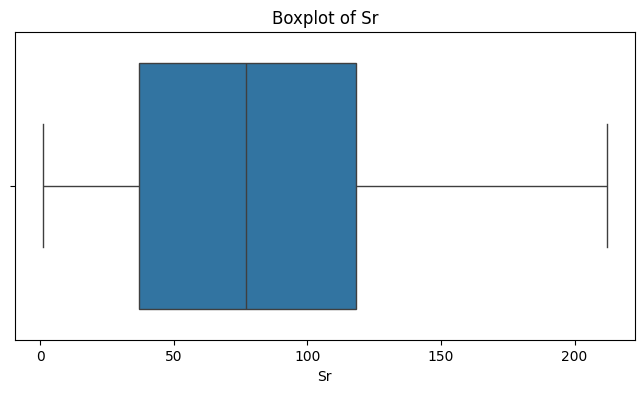

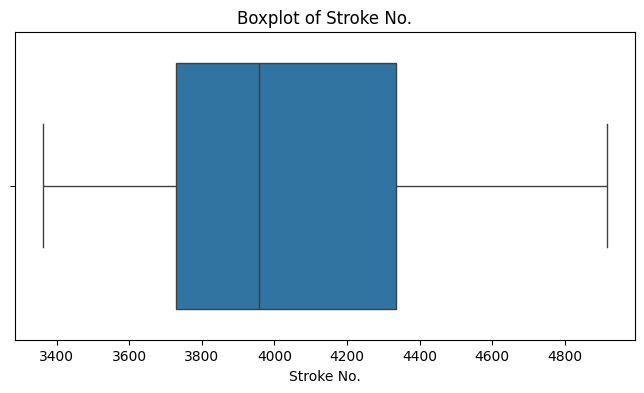

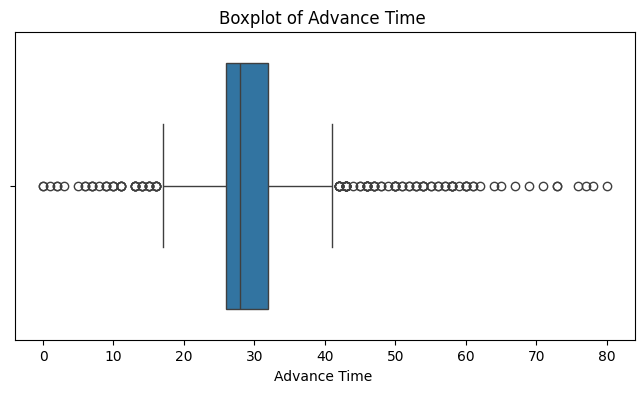

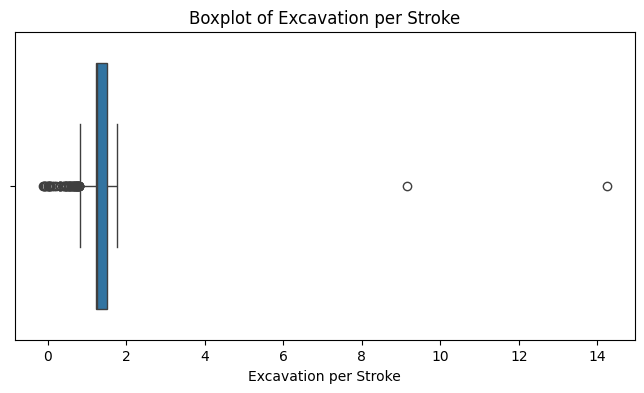

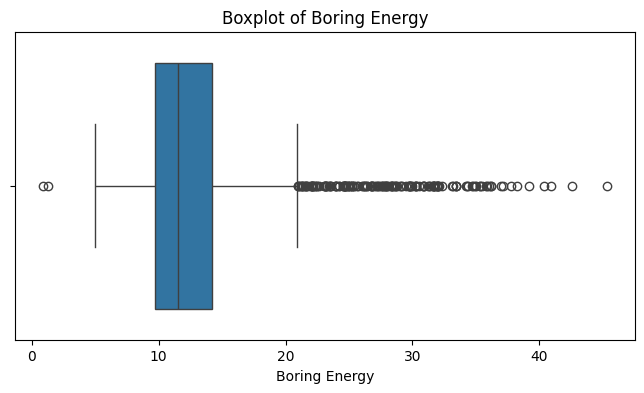

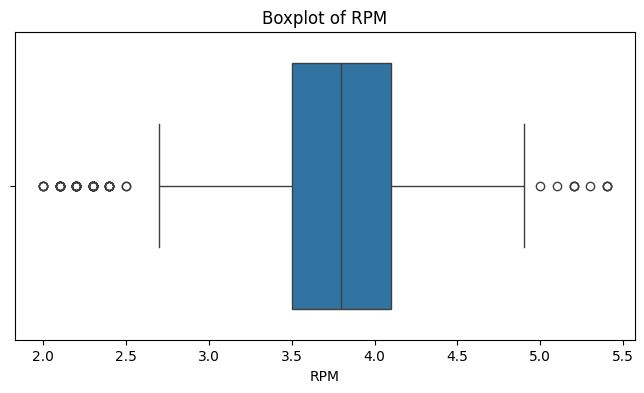

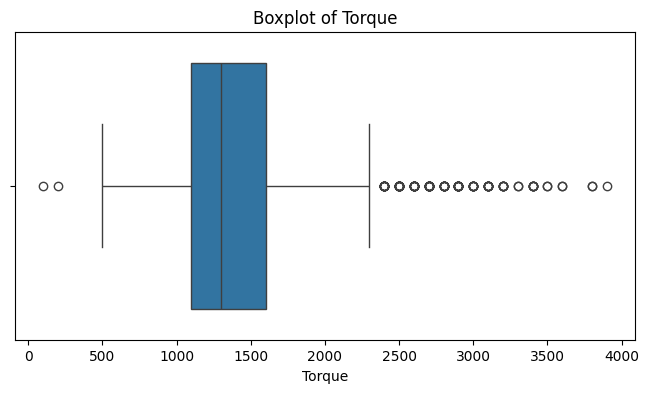

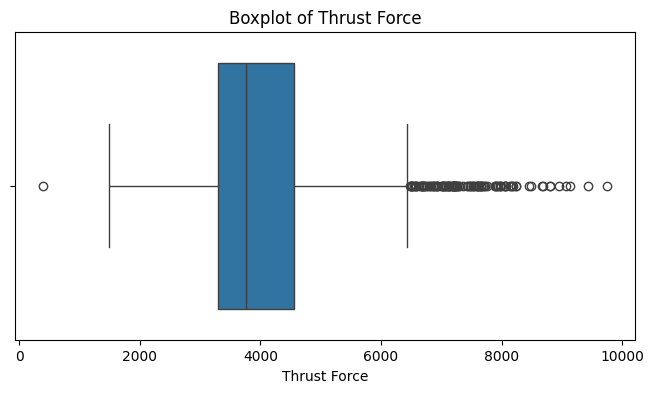

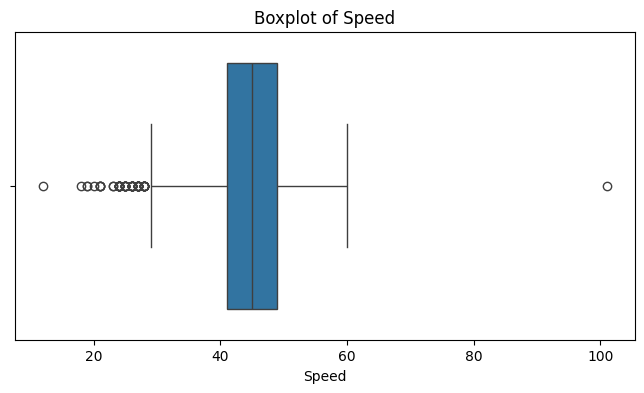

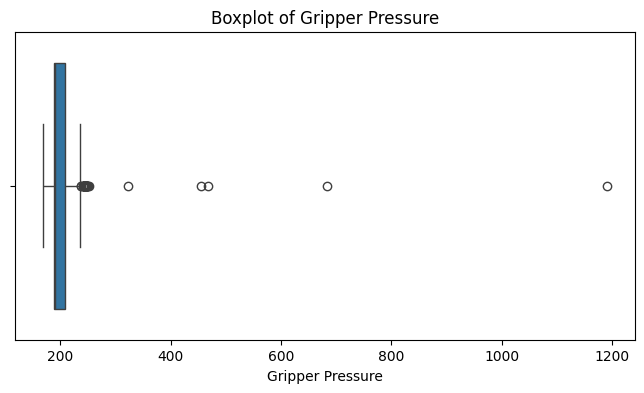

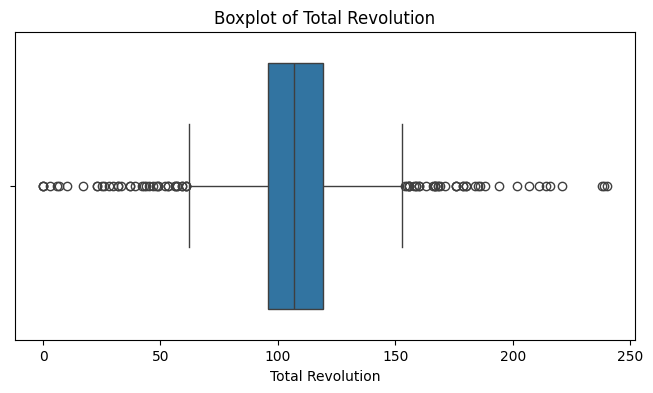

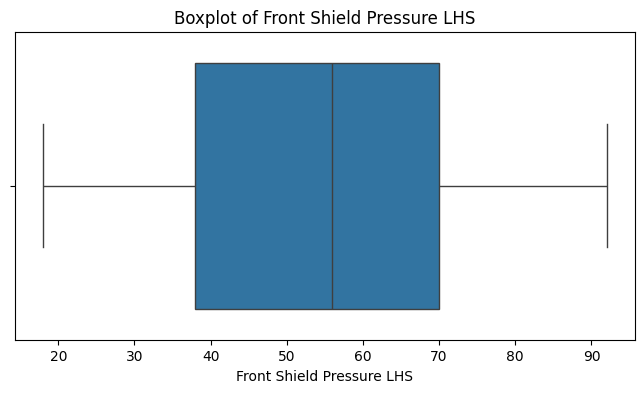

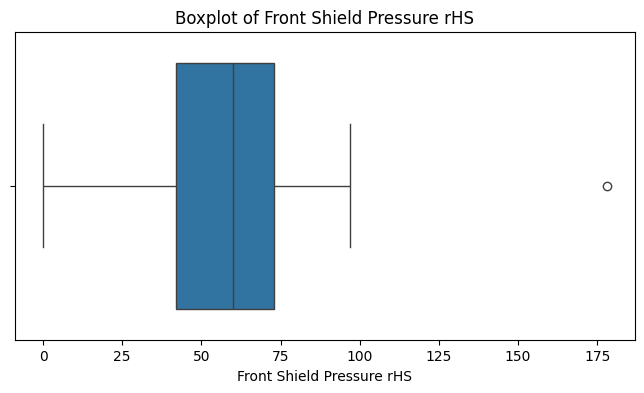

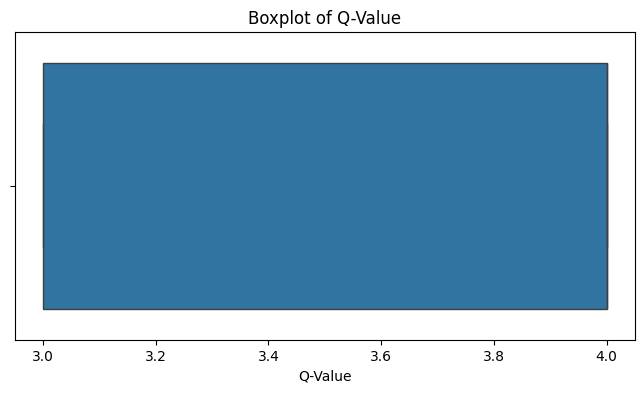

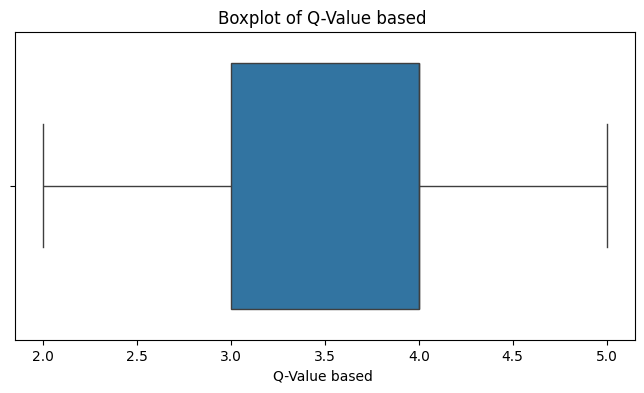

: 

In [ ]:
# checking outliers using boxplots
num_cols = df.select_dtypes(include=[np.number]).columns
for col in num_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

The graph show outliers in the  dataset according to the quantile method.BUt in real these values are not outliers because they are possible values for the features. So we will not remove them.

#### 3.5 Feature Scaling

In [ ]:
df.columns

Index(['Sr', 'Stroke No.', 'Date', 'Advance Time ', 'Excavation per Stroke', 'Boring Energy', 'RPM', 'Torque', 'Thrust Force', 'Speed', 'Gripper Pressure', 'Total Revolution',
       'Front Shield Pressure LHS', 'Front Shield Pressure rHS', 'Q-Value', 'Q-Value based ', 'PR_Class'],
      dtype='object')

: 

In [ ]:
# scaling the numeric columns
scaler = StandardScaler()
for col in num_cols:
    df[col] = scaler.fit_transform(df[[col]])
    

: 

feature scaling is very important for algorithm like svm and Regression

### 4. Exploratory Data Analysis (EDA)

: 